# 02 — Image Preprocessing

## Dataset
CASIA-Iris-Thousand

## Objective
Prepare the CASIA-Iris-Thousand dataset for the subsequent
diffusion model training and ocular recognition experiments.

## Preprocessing Steps
1. Load the dataset
2. Create identity-wise train/validation/test splits
3. Resize images
4. Normalize pixel values
5. Verify the preprocessed data
6. Save the preprocessing information

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from pathlib import Path

# Main project folder
project_path = Path("/content/drive/MyDrive/Ocular_Project")

# CASIA-Iris-Thousand dataset
dataset_path = (
    project_path
    / "datasets"
    / "CASIA-Iris-Thousand"
    / "CASIA-Iris-Thousand"
)

print("Dataset path:")
print(dataset_path)

print("\nDataset exists:", dataset_path.exists())

Dataset path:
/content/drive/MyDrive/Ocular_Project/datasets/CASIA-Iris-Thousand/CASIA-Iris-Thousand

Dataset exists: True


In [4]:
# Check the actual folder structure

items = list(dataset_path.iterdir())

print("Number of items inside dataset folder:", len(items))

print("\nFirst 10 items:")
for item in items[:10]:
    print(item.name, " | is_dir =", item.is_dir())

print("\nChecking subject 000:")

subject_000 = dataset_path / "000"

print("Subject 000 exists:", subject_000.exists())
print("Subject 000 is directory:", subject_000.is_dir())

if subject_000.exists():
    print("\nContents of subject 000:")
    for item in subject_000.iterdir():
        print(item.name, " | is_dir =", item.is_dir())

Number of items inside dataset folder: 1

First 10 items:
CASIA-Iris-Thousand  | is_dir = True

Checking subject 000:
Subject 000 exists: False
Subject 000 is directory: False


In [5]:
# Correct dataset path

dataset_path = (
    project_path
    / "datasets"
    / "CASIA-Iris-Thousand"
    / "CASIA-Iris-Thousand"
    / "CASIA-Iris-Thousand"
)

print("Correct dataset path:")
print(dataset_path)

print("\nDataset exists:", dataset_path.exists())

print("\nFirst 10 items:")
for item in list(dataset_path.iterdir())[:10]:
    print(item.name, "| is_dir =", item.is_dir())

Correct dataset path:
/content/drive/MyDrive/Ocular_Project/datasets/CASIA-Iris-Thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand

Dataset exists: True

First 10 items:
000 | is_dir = True
001 | is_dir = True
002 | is_dir = True
003 | is_dir = True
004 | is_dir = True
005 | is_dir = True
006 | is_dir = True
007 | is_dir = True
008 | is_dir = True
009 | is_dir = True


In [6]:
# Collect all eye identities

eye_identities = []

for subject_folder in sorted(dataset_path.iterdir()):
    if subject_folder.is_dir():
        subject_id = subject_folder.name

        for eye in ["L", "R"]:
            eye_folder = subject_folder / eye

            if eye_folder.exists() and eye_folder.is_dir():
                eye_identities.append(f"{subject_id}_{eye}")

print("Total eye identities:", len(eye_identities))

print("\nFirst 20 eye identities:")
for identity in eye_identities[:20]:
    print(identity)

Total eye identities: 2000

First 20 eye identities:
000_L
000_R
001_L
001_R
002_L
002_R
003_L
003_R
004_L
004_R
005_L
005_R
006_L
006_R
007_L
007_R
008_L
008_R
009_L
009_R


In [7]:
import pandas as pd

# Store train/validation/test information
split_records = []

# Process every eye identity
for subject_folder in sorted(dataset_path.iterdir()):

    if not subject_folder.is_dir():
        continue

    subject_id = subject_folder.name

    for eye in ["L", "R"]:

        eye_folder = subject_folder / eye

        if not eye_folder.exists():
            continue

        # Get all images and sort them
        images = sorted(eye_folder.glob("*.jpg"))

        # We expect exactly 10 images per eye identity
        if len(images) != 10:
            print(f"Warning: {subject_id}_{eye} has {len(images)} images")

        # Split
        train_images = images[:6]
        val_images = images[6:8]
        test_images = images[8:10]

        # Add training images
        for image_path in train_images:
            split_records.append({
                "image_path": str(image_path),
                "identity": f"{subject_id}_{eye}",
                "subject": subject_id,
                "eye": eye,
                "split": "train"
            })

        # Add validation images
        for image_path in val_images:
            split_records.append({
                "image_path": str(image_path),
                "identity": f"{subject_id}_{eye}",
                "subject": subject_id,
                "eye": eye,
                "split": "validation"
            })

        # Add test images
        for image_path in test_images:
            split_records.append({
                "image_path": str(image_path),
                "identity": f"{subject_id}_{eye}",
                "subject": subject_id,
                "eye": eye,
                "split": "test"
            })


# Convert to DataFrame
split_df = pd.DataFrame(split_records)

print("Total images:", len(split_df))
print("\nImages in each split:")
print(split_df["split"].value_counts())

print("\nUnique eye identities:")
print(split_df["identity"].nunique())

Total images: 20000

Images in each split:
split
train         12000
validation     4000
test           4000
Name: count, dtype: int64

Unique eye identities:
2000


In [8]:
# Save the train/validation/test split information

split_csv_path = project_path / "results" / "CASIA_Thousand_data_split.csv"

split_df.to_csv(split_csv_path, index=False)

print("Split information saved successfully!")
print("File:", split_csv_path)
print("Rows:", len(split_df))

Split information saved successfully!
File: /content/drive/MyDrive/Ocular_Project/results/CASIA_Thousand_data_split.csv
Rows: 20000


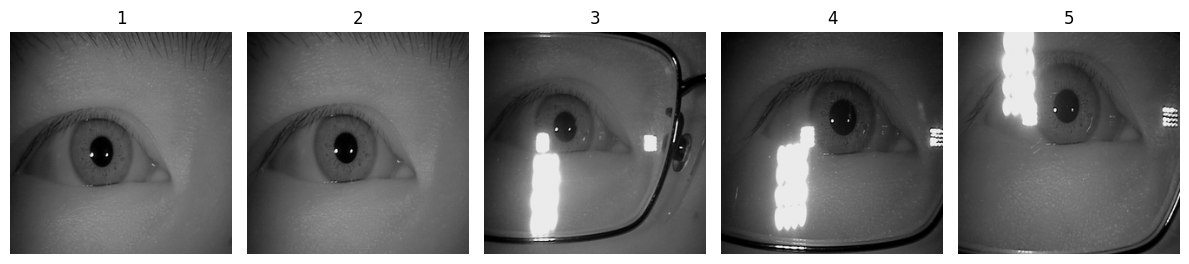

In [9]:
from PIL import Image
import matplotlib.pyplot as plt

# Select 5 sample images
sample_images = split_df["image_path"].head(5).tolist()

plt.figure(figsize=(12, 5))

for i, image_path in enumerate(sample_images):

    # Load original image
    img = Image.open(image_path).convert("L")

    # Resize to 256 x 256
    resized_img = img.resize((256, 256), Image.Resampling.LANCZOS)

    # Display resized image
    plt.subplot(1, 5, i + 1)
    plt.imshow(resized_img, cmap="gray")
    plt.title(f"{i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

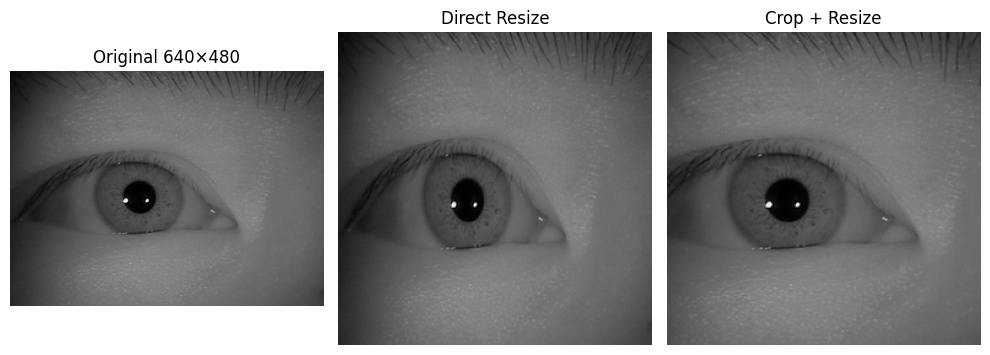

In [10]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = split_df["image_path"].iloc[0]

img = Image.open(image_path).convert("L")

# Method 1: Direct resize
direct_resize = img.resize((256, 256), Image.Resampling.LANCZOS)

# Method 2: Center crop + resize
width, height = img.size

crop_size = min(width, height)

left = (width - crop_size) // 2
top = (height - crop_size) // 2
right = left + crop_size
bottom = top + crop_size

cropped = img.crop((left, top, right, bottom))
crop_resize = cropped.resize((256, 256), Image.Resampling.LANCZOS)

# Display comparison
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original 640×480")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(direct_resize, cmap="gray")
plt.title("Direct Resize")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(crop_resize, cmap="gray")
plt.title("Crop + Resize")
plt.axis("off")

plt.tight_layout()
plt.show()

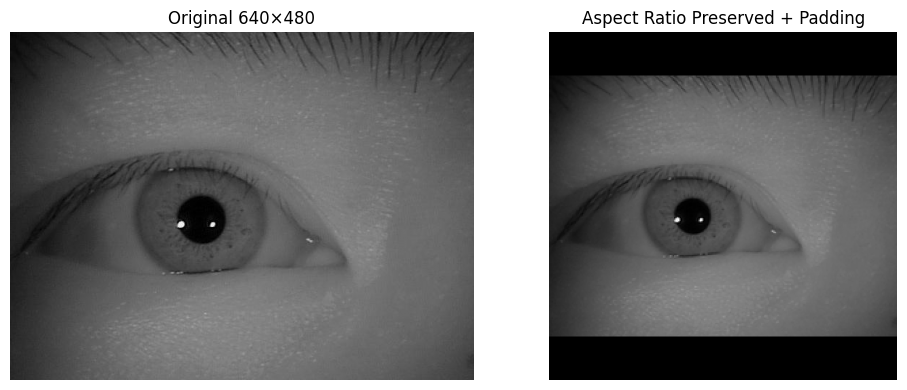

Original size: (640, 480)
Resized size: (256, 192)
Final size: (256, 256)


In [11]:
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

image_path = split_df["image_path"].iloc[0]

# Load original
img = Image.open(image_path).convert("L")

# Resize while preserving aspect ratio
resized = ImageOps.contain(
    img,
    (256, 256),
    method=Image.Resampling.LANCZOS
)

# Create 256x256 canvas
padded = Image.new("L", (256, 256), color=0)

# Put resized image in the center
x = (256 - resized.width) // 2
y = (256 - resized.height) // 2

padded.paste(resized, (x, y))

# Display
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original 640×480")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(padded, cmap="gray")
plt.title("Aspect Ratio Preserved + Padding")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Original size:", img.size)
print("Resized size:", resized.size)
print("Final size:", padded.size)

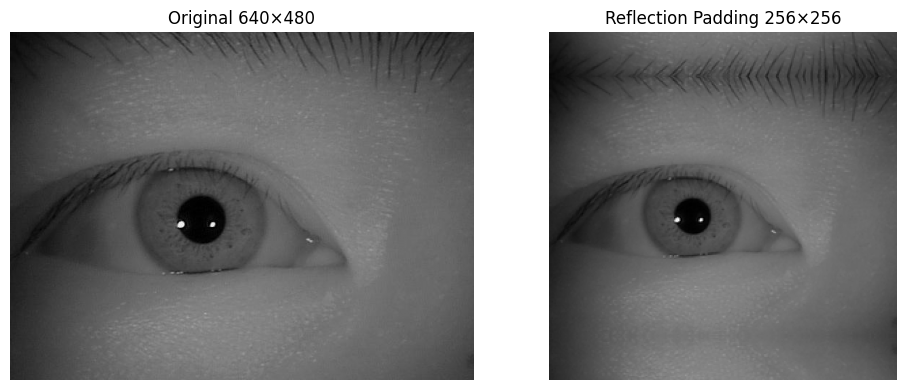

Original size: (640, 480)
Resized size: (256, 192)
Final size: (256, 256)


In [12]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

image_path = split_df["image_path"].iloc[0]

# Load image
img = Image.open(image_path).convert("L")

# Resize while preserving aspect ratio
resized = img.resize((256, 192), Image.Resampling.LANCZOS)

# Convert to NumPy
img_array = np.array(resized)

# Calculate vertical padding
padding_total = 256 - 192
padding_top = padding_total // 2
padding_bottom = padding_total - padding_top

# Reflection padding
padded_array = np.pad(
    img_array,
    ((padding_top, padding_bottom), (0, 0)),
    mode="reflect"
)

# Convert back to PIL
padded_reflect = Image.fromarray(padded_array)

# Display
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original 640×480")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(padded_reflect, cmap="gray")
plt.title("Reflection Padding 256×256")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Original size:", img.size)
print("Resized size:", resized.size)
print("Final size:", padded_reflect.size)

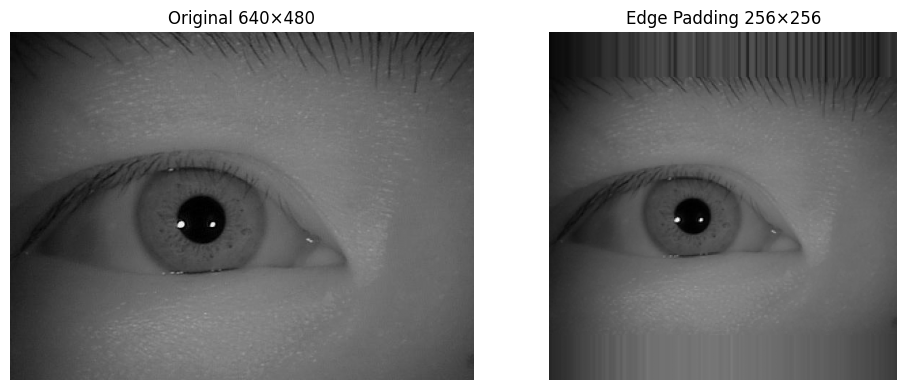

Original size: (640, 480)
Resized size: (256, 192)
Final size: (256, 256)


In [13]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

image_path = split_df["image_path"].iloc[0]

# Load image
img = Image.open(image_path).convert("L")

# Resize while preserving aspect ratio
resized = img.resize((256, 192), Image.Resampling.LANCZOS)

# Convert to NumPy
img_array = np.array(resized)

# Add edge padding
padding_total = 256 - 192
padding_top = padding_total // 2
padding_bottom = padding_total - padding_top

padded_array = np.pad(
    img_array,
    ((padding_top, padding_bottom), (0, 0)),
    mode="edge"
)

# Convert back to image
padded_edge = Image.fromarray(padded_array)

# Display
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original 640×480")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(padded_edge, cmap="gray")
plt.title("Edge Padding 256×256")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Original size:", img.size)
print("Resized size:", resized.size)
print("Final size:", padded_edge.size)

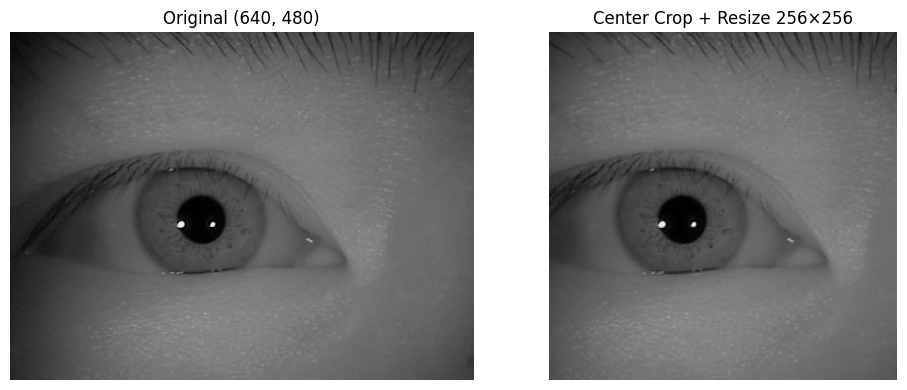

Original size: (640, 480)
Crop size: (480, 480)
Final size: (256, 256)


In [14]:
from PIL import Image
import matplotlib.pyplot as plt

# Take one image from the dataset
image_path = split_df["image_path"].iloc[0]

img = Image.open(image_path).convert("L")

# Original dimensions
w, h = img.size

# Make a square crop using the smaller dimension
crop_size = min(w, h)

# Center crop
left = (w - crop_size) // 2
top = (h - crop_size) // 2
right = left + crop_size
bottom = top + crop_size

cropped = img.crop((left, top, right, bottom))

# Resize to 256x256
cropped_resized = cropped.resize(
    (256, 256),
    Image.Resampling.LANCZOS
)

# Display
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title(f"Original {img.size}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cropped_resized, cmap="gray")
plt.title("Center Crop + Resize 256×256")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Original size:", img.size)
print("Crop size:", cropped.size)
print("Final size:", cropped_resized.size)

Before normalization:
Minimum: 0.0
Maximum: 255.0

After normalization:
Minimum: 0.0
Maximum: 1.0

Data type: float32


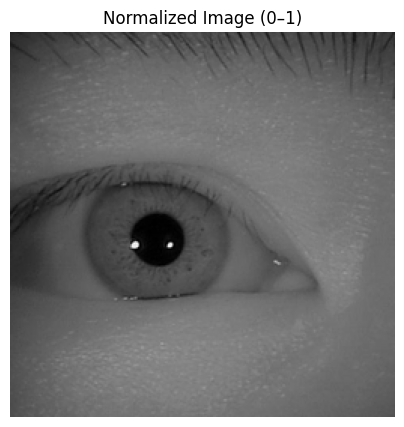

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Convert processed image to NumPy array
img_array = np.array(cropped_resized).astype(np.float32)

# Normalize pixel values from [0, 255] to [0, 1]
normalized_img = img_array / 255.0

print("Before normalization:")
print("Minimum:", img_array.min())
print("Maximum:", img_array.max())

print("\nAfter normalization:")
print("Minimum:", normalized_img.min())
print("Maximum:", normalized_img.max())

print("\nData type:", normalized_img.dtype)

# Display normalized image
plt.figure(figsize=(5, 5))
plt.imshow(normalized_img, cmap="gray")
plt.title("Normalized Image (0–1)")
plt.axis("off")
plt.show()

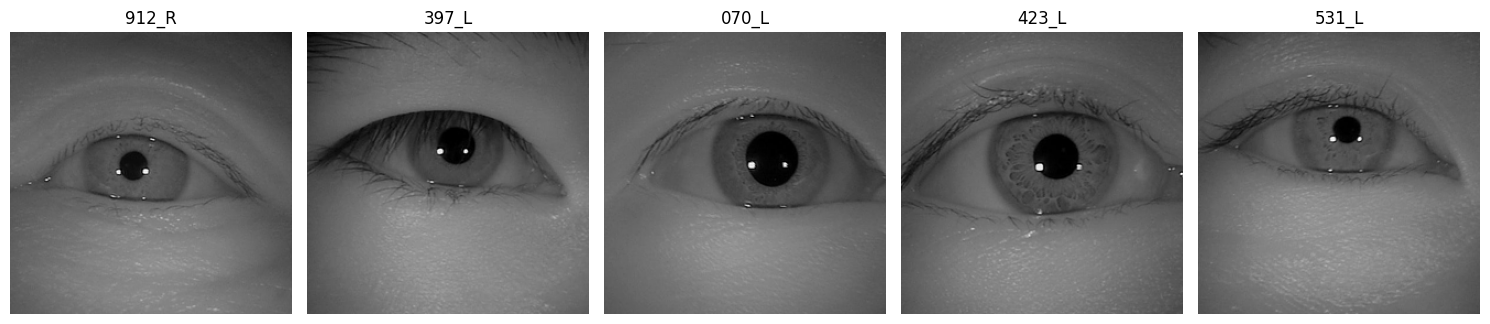

In [16]:
# Check preprocessing on images from different identities

import random
import matplotlib.pyplot as plt
from PIL import Image

# Select 5 different eye identities
sample_identities = random.sample(
    split_df["identity"].unique().tolist(),
    5
)

plt.figure(figsize=(15, 8))

for i, identity in enumerate(sample_identities):

    # Get one image belonging to this identity
    row = split_df[split_df["identity"] == identity].iloc[0]

    image_path = row["image_path"]

    # Load image
    img = Image.open(image_path).convert("L")

    # Center crop
    w, h = img.size
    crop_size = min(w, h)

    left = (w - crop_size) // 2
    top = (h - crop_size) // 2
    right = left + crop_size
    bottom = top + crop_size

    cropped = img.crop((left, top, right, bottom))

    # Resize
    processed = cropped.resize(
        (256, 256),
        Image.Resampling.LANCZOS
    )

    # Display
    plt.subplot(1, 5, i + 1)
    plt.imshow(processed, cmap="gray")
    plt.title(identity)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
from PIL import Image
import numpy as np

def preprocess_image(image_path, size=256):
    """
    Load and preprocess one CASIA-Iris-Thousand image.

    Steps:
    1. Convert to grayscale
    2. Center crop to square
    3. Resize to 256x256
    4. Normalize pixel values to [0, 1]
    """

    # Load image
    img = Image.open(image_path).convert("L")

    # Get dimensions
    width, height = img.size

    # Center crop using the smaller dimension
    crop_size = min(width, height)

    left = (width - crop_size) // 2
    top = (height - crop_size) // 2
    right = left + crop_size
    bottom = top + crop_size

    img = img.crop((left, top, right, bottom))

    # Resize
    img = img.resize(
        (size, size),
        Image.Resampling.LANCZOS
    )

    # Convert to NumPy
    img_array = np.array(img).astype(np.float32)

    # Normalize to [0, 1]
    img_array = img_array / 255.0

    return img_array


# Test the function
test_path = split_df["image_path"].iloc[0]

processed_image = preprocess_image(test_path)

print("Processed shape:", processed_image.shape)
print("Minimum pixel value:", processed_image.min())
print("Maximum pixel value:", processed_image.max())
print("Data type:", processed_image.dtype)

Processed shape: (256, 256)
Minimum pixel value: 0.0
Maximum pixel value: 1.0
Data type: float32


In [18]:
# Verify preprocessing on multiple images

import numpy as np

sample_paths = split_df["image_path"].sample(
    n=20,
    random_state=42
).tolist()

failed = []

for path in sample_paths:
    try:
        processed = preprocess_image(path)

        # Check expected shape
        if processed.shape != (256, 256):
            failed.append((path, "Wrong shape"))

        # Check normalization range
        if processed.min() < 0 or processed.max() > 1:
            failed.append((path, "Wrong pixel range"))

        # Check data type
        if processed.dtype != np.float32:
            failed.append((path, "Wrong data type"))

    except Exception as e:
        failed.append((path, str(e)))

print("Images tested:", len(sample_paths))
print("Failed:", len(failed))

if len(failed) == 0:
    print("\n✅ All preprocessing checks passed!")
else:
    print("\n❌ Some images failed:")
    for item in failed:
        print(item)

Images tested: 20
Failed: 0

✅ All preprocessing checks passed!


In [19]:
# Save preprocessing configuration

import json

preprocessing_config = {
    "dataset": "CASIA-Iris-Thousand",
    "original_size": "640x480",
    "crop_method": "center_crop",
    "crop_size": "480x480",
    "resize_method": "LANCZOS",
    "final_size": "256x256",
    "color_mode": "grayscale",
    "normalization": "[0, 1]",
    "data_type": "float32"
}

config_path = project_path / "results" / "CASIA_Thousand_preprocessing_config.json"

with open(config_path, "w") as f:
    json.dump(preprocessing_config, f, indent=4)

print("Preprocessing configuration saved successfully!")
print("File:", config_path)

Preprocessing configuration saved successfully!
File: /content/drive/MyDrive/Ocular_Project/results/CASIA_Thousand_preprocessing_config.json
